# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) summarizes genome-wide genotype variation into a small number of axes called principal components (PCs). In population genetics, the first few PCs often capture broad ancestry structure, sample outliers, or batch effects.

This tutorial shows how to:

- Load a representative subset of 1000 Genomes Project samples with population metadata
- Perform PCA with the scikit-learn CPU backend using low-rank SVD
- Perform PCA with the PyTorch backend using exact SVD on a GPU when available
- Calculate PC coordinates in one step or compute eigenvectors first and then project samples
- Visualize PC coordinates and color samples by population metadata

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from snputils.datasets import load_dataset
from snputils.processing import PCA, embedding_dataframe_from_model
from snputils.visualization import plot_embedding

## Load a 1000 Genomes subset

The code below loads 10 populations from the 1000 Genomes Project Phase 3 panel, taking up to 50 samples per population and 100,000 SNPs.

The selected population labels are stored on the returned `SNPObject` as `sample_fid`, aligned to `snpobj.samples`. The genotype array is kept as two strands per individual (`sum_strands=False`); the PCA examples below average those strands into one genotype dosage per sample.

In [ ]:
DATA_DIR = Path("data/1kgp")

populations = [
    "YRI", "MSL", "GWD", "CEU", "GBR", 
    "IBS", "CHB", "JPT", "GIH", "PEL",
]

# Once the data is downloaded in DATA_DIR, loading it should only take less than 2 minutes.
snpobj = load_dataset(
    "1kgp",
    download_genotypes=True,
    resource="phase3",
    output_dir=DATA_DIR,
    populations=populations,
    samples_per_population=50,
    max_variants=100_000,
    require_biallelic=True,
    require_complete=True,
    require_polymorphic=True,
    snv_only=True,
    sum_strands=False,
)

print(f"Loaded {snpobj.n_samples:,} samples and {snpobj.n_snps:,} variants")
print(f"Genotype array shape: {snpobj.genotypes.shape}")

Loaded 500 samples and 100,000 variants
Genotype array shape: (100000, 500, 2)


Create a metadata table that will be reused when plotting PC coordinates. Each row represents one individual.

In [3]:
sample_metadata = pd.DataFrame({
    "sample": snpobj.samples,
    "population": snpobj.sample_fid,
    "sex": snpobj.sample_sex,
})

sample_metadata

,sample,population,sex
0,HG00096,GBR,M
1,HG00097,GBR,F
2,HG00099,GBR,F
3,HG00100,GBR,F
4,HG00101,GBR,M
...,...,...,...
495,NA20902,GIH,F
496,NA20903,GIH,M
497,NA20904,GIH,M
498,NA20905,GIH,M


## Build tables and plots with snputils utilities

`PCA.fit_transform()` and `PCA.transform()` store projected coordinates. snputils provides `embedding_dataframe_from_model()` to convert those coordinates into a table with `PC1`, `PC2`, etc., and sample identifiers, and `plot_embedding()` to make metadata-colored scatter plots from that table.


## PCA on CPU with low-rank SVD

The sklearn backend always runs on CPU. Setting `fitting="lowrank"` uses a randomized low-rank SVD, which is often a practical choice when the goal is to calculate the first few PCs from a large genotype matrix.

Here `fit_transform()` computes the eigenvectors and immediately projects the same samples onto the requested PCs.

In [4]:
%%time
pca_cpu = PCA(
    backend="sklearn",
    n_components=10,
    fitting="lowrank",
    average_strands=True,
)

coords_cpu = pca_cpu.fit_transform(snpobj)
coords_cpu_df = embedding_dataframe_from_model(pca_cpu, metadata=sample_metadata)
coords_cpu_df

CPU times: user 3min 35s, sys: 252 ms, total: 3min 35s
Wall time: 16.3 s


,indID,method,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,population,sex
0,HG00096,pca,-5.445668,-13.814376,-2.301814,-1.244111,-6.680630,-3.717565,-0.317790,-1.471880,5.344683,-3.964763,GBR,M
1,HG00097,pca,-9.220740,-10.856742,-1.274107,2.944276,8.447960,-4.819750,-8.208855,-5.760562,-2.643495,2.121280,GBR,F
2,HG00099,pca,-10.290048,-12.828224,5.822768,-7.014384,-6.646201,-3.529025,-5.580506,-0.436918,10.338888,2.512376,GBR,F
3,HG00100,pca,-8.672443,-11.465423,-1.752690,-3.504632,0.428147,6.366216,4.551703,2.242306,-2.266150,2.665156,GBR,F
4,HG00101,pca,-10.551410,-7.101886,1.762160,-4.699048,-2.456534,-9.979330,3.919668,-4.201518,-0.775524,-2.900219,GBR,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,NA20902,pca,-9.311613,2.114745,-4.715104,-2.613610,14.008947,-5.364798,6.982087,2.001102,-2.000129,12.701165,GIH,F
496,NA20903,pca,-6.888755,-8.312722,-4.942655,0.221704,2.450688,4.242626,-5.060560,4.646278,6.622268,-2.037378,GIH,M
497,NA20904,pca,-9.226455,-4.702215,-1.251491,-4.237715,-0.598488,4.642883,-1.589584,-0.740125,4.006232,1.004840,GIH,M
498,NA20905,pca,-8.176906,-1.238093,-3.162771,-5.514153,5.755089,3.472307,5.553517,-4.196957,7.590596,10.594611,GIH,M


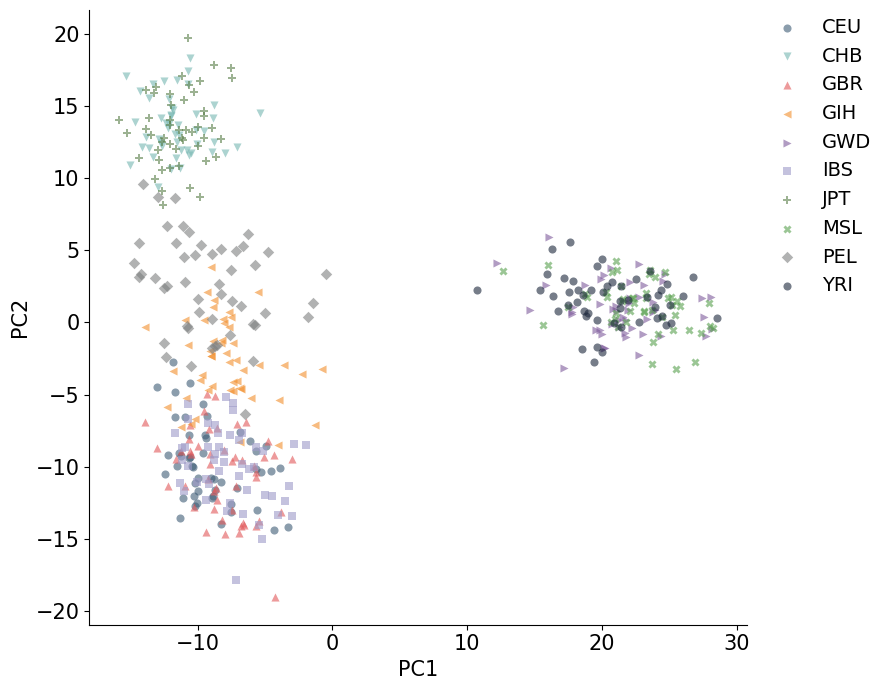

In [5]:
plot_embedding(coords_cpu_df, hue="population")
plt.show()

## Compute eigenvectors, then project samples

Sometimes it is useful to separate the two steps:

1. `fit()` computes the PCA eigenvectors from a set of samples and variants.
2. `transform()` projects genotype data onto those PCs, and you can also project new data which was not used to compute the eigenvectors.

The example below computes eigenvectors from the loaded dataset and then projects the samples.

In [6]:
pca_two_step = PCA(
    backend="sklearn",
    n_components=4,
    fitting="lowrank",
    average_strands=True,
)

pca_two_step.fit(snpobj)
coords_projected = pca_two_step.transform(snpobj)
coords_projected_df = embedding_dataframe_from_model(pca_two_step, metadata=sample_metadata)

coords_projected_df

,indID,method,PC1,PC2,PC3,PC4,population,sex
0,HG00096,pca,-5.445668,-13.814338,-2.253621,-1.215476,GBR,M
1,HG00097,pca,-9.220740,-10.856771,-1.279904,2.900660,GBR,F
2,HG00099,pca,-10.290048,-12.828216,5.841178,-7.012531,GBR,F
3,HG00100,pca,-8.672443,-11.465432,-1.751666,-3.533308,GBR,F
4,HG00101,pca,-10.551410,-7.101853,1.827255,-4.676792,GBR,M
...,...,...,...,...,...,...,...,...
495,NA20902,pca,-9.311613,2.114709,-4.768888,-2.651646,GIH,F
496,NA20903,pca,-6.888755,-8.312735,-4.990218,0.221016,GIH,M
497,NA20904,pca,-9.226455,-4.702213,-1.256812,-4.232951,GIH,M
498,NA20905,pca,-8.176906,-1.238123,-3.207110,-5.533290,GIH,M


After `fit()`, the principal axes are available in `components_`. Each row is one eigenvector, and each column corresponds to one variant used in the PCA calculation.

In [7]:
print(f"Number of PCs computed: {pca_two_step.n_components_}")
print(f"Eigenvector matrix shape: {pca_two_step.components_.shape}")

Number of PCs computed: 4
Eigenvector matrix shape: (4, 100000)


## PCA on GPU with exact SVD

The `pytorch` backend can run PCA on a CUDA GPU. Setting `fitting="exact"` uses an exact SVD. If CUDA is unavailable, `device="cuda:0"` falls back to CPU with a warning, so the code remains runnable on a laptop while still showing the GPU configuration.

Exact SVD can be useful when you want deterministic full-SVD behavior for a selected number of PCs and have enough GPU memory for the selected genotype matrix.

In [8]:
%%time
pca_gpu = PCA(
    backend="pytorch",
    n_components=10,
    fitting="exact",
    device="cuda:0",
    average_strands=True,
)

coords_gpu = pca_gpu.fit_transform(snpobj)
coords_gpu_df = embedding_dataframe_from_model(pca_gpu, metadata=sample_metadata)

print(f"PyTorch PCA device: {pca_gpu.device}")
coords_gpu_df

Converting data to PyTorch tensor on device cuda:0
PyTorch PCA device: cuda:0
CPU times: user 3.74 s, sys: 681 ms, total: 4.42 s
Wall time: 4.23 s


,indID,method,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,population,sex
0,HG00096,pca,-5.445668,-13.814376,-2.302600,1.240161,-6.667645,-3.794875,-0.166289,1.317343,5.105976,-3.670369,GBR,M
1,HG00097,pca,-9.220740,-10.856746,-1.269752,-2.940157,8.468375,-4.897522,-7.814991,5.632787,-2.985812,2.463613,GBR,F
2,HG00099,pca,-10.290048,-12.828221,5.820676,7.014180,-6.644298,-3.812626,-5.505681,0.458062,10.347920,2.704303,GBR,F
3,HG00100,pca,-8.672443,-11.465423,-1.750988,3.513406,0.381993,6.500455,4.294257,-2.217475,-2.083600,2.720650,GBR,F
4,HG00101,pca,-10.551410,-7.101874,1.757486,4.687729,-2.473735,-10.157563,4.045995,4.234613,-0.680950,-2.863122,GBR,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,NA20902,pca,-9.311613,2.114750,-4.714011,2.615123,14.015300,-5.178370,7.097056,-1.831070,-1.849865,12.583123,GIH,F
496,NA20903,pca,-6.888755,-8.312712,-4.947268,-0.228888,2.459371,3.590458,-5.735509,-4.652354,6.701974,-2.289744,GIH,M
497,NA20904,pca,-9.226455,-4.702216,-1.251564,4.228626,-0.535143,4.553773,-1.794397,0.759041,4.000025,0.816303,GIH,M
498,NA20905,pca,-8.176906,-1.238097,-3.161562,5.514553,5.749235,3.756734,5.473292,4.269050,7.260847,10.549923,GIH,M


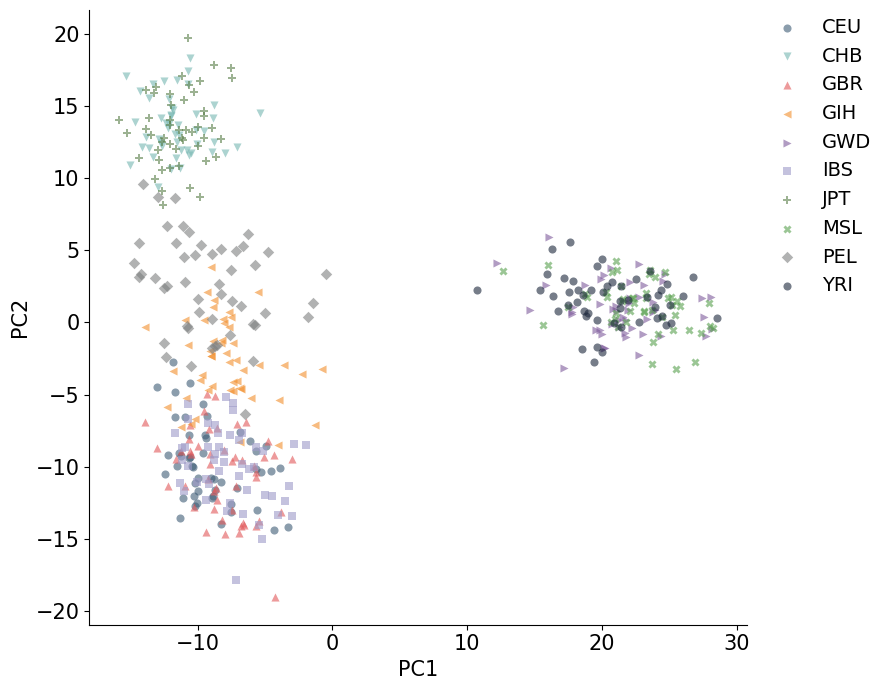

In [9]:
plot_embedding(coords_gpu_df, hue="population")
plt.show()

## Color PCA Plots by population groups

The population metadata can also be collapsed into broader groups for a less crowded plot. The grouping below is only for visualization; the PCA coordinates are the same.

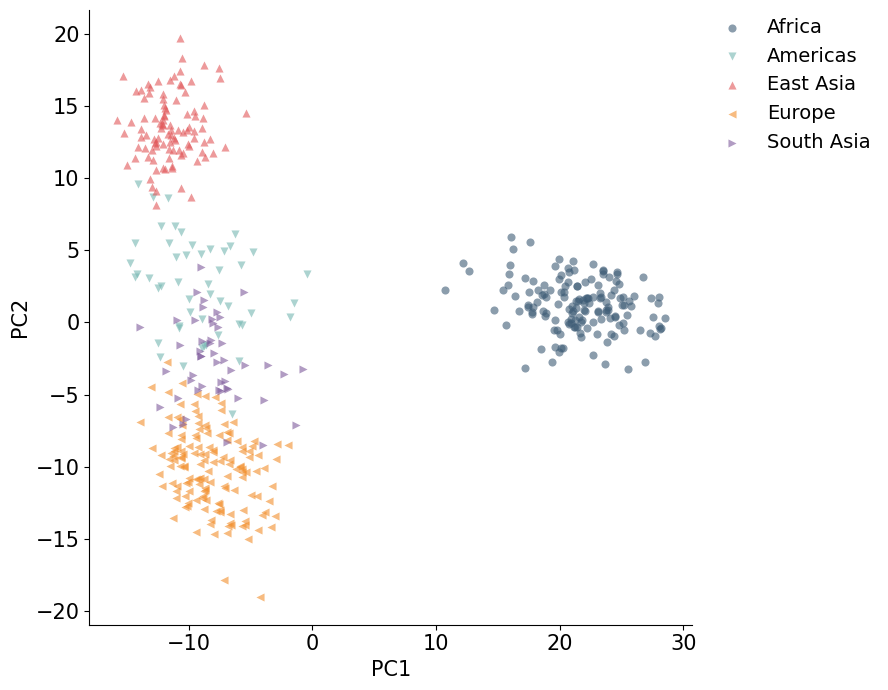

In [10]:
population_group = {
    "YRI": "Africa", "LWK": "Africa", "MSL": "Africa", "GWD": "Africa",
    "CEU": "Europe", "FIN": "Europe", "GBR": "Europe", "IBS": "Europe",
    "CHB": "East Asia", "JPT": "East Asia",
    "GIH": "South Asia",
    "PEL": "Americas",
}

coords_cpu_df["population_group"] = coords_cpu_df["population"].map(population_group)
plot_embedding(coords_cpu_df, hue="population_group")
plt.show()

## Using sample and variant subsets

`PCA` can select rows and columns before computing PCs. `samples_subset` chooses samples by row index, and `snps_subset` chooses variants by column index. Passing an integer uses the first `n` rows or columns; passing a list uses the specified indices.

This is helpful for quick exploratory PCA calculations before scaling up to the full selected dataset.

Subset PC coordinate shape: (200, 4)


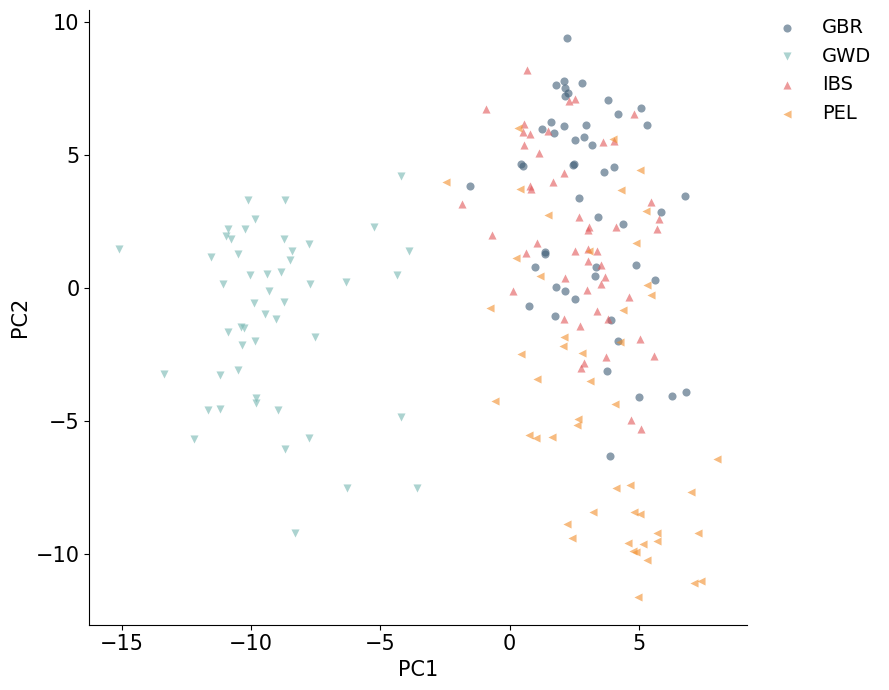

CPU times: user 36.1 s, sys: 144 ms, total: 36.2 s
Wall time: 3.36 s


In [11]:
%%time
pca_subset = PCA(
    backend="sklearn",
    n_components=4,
    fitting="lowrank",
    average_strands=True,
    samples_subset=200,
    snps_subset=20_000,
)

coords_subset = pca_subset.fit_transform(snpobj)
coords_subset_df = embedding_dataframe_from_model(pca_subset, metadata=sample_metadata)

print(f"Subset PC coordinate shape: {coords_subset.shape}")
plot_embedding(coords_subset_df, hue="population")
plt.show()

## Save PC coordinates

If `embedding_table_path` is set, `fit_transform()` writes the projected PC coordinates to a TSV or CSV file. This is useful when PC coordinates will be used by another analysis or plotting script.

In [12]:
output_path = "pca_coordinates.tsv"

pca_export = PCA(
    backend="sklearn",
    n_components=4,
    fitting="lowrank",
    average_strands=True,
    embedding_table_path=output_path,
)
_ = pca_export.fit_transform(snpobj)

print(f"Wrote PCA coordinates to {output_path}")

Wrote PCA coordinates to pca_coordinates.tsv
